In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

# Qiskit & Optimization imports
from qiskit_aer import AerSimulator
from qiskit_algorithms import QAOA
from qiskit_algorithms.optimizers import COBYLA
from qiskit_optimization import QuadraticProgram
from qiskit_optimization.algorithms import MinimumEigenOptimizer
from qiskit_optimization.converters import QuadraticProgramToQubo

In [2]:
tickers = ['BBCA.JK', 'TLKM.JK', 'ASII.JK', 'BMRI.JK']
data = yf.download(tickers, start='2024-01-01', end='2025-01-01')['Close']

# Hitung expected return tahunan dan matriks kovariansi
daily_returns = data.pct_change().dropna()
mu = daily_returns.mean().values * 252       # Expected return
sigma = daily_returns.cov().values * 252      # Covariance matrix

print("Expected Returns (μ):", np.round(mu, 4))
print("\nCovariance Matrix (Σ):\n", np.round(sigma, 4))

[*********************100%***********************]  4 of 4 completed

Expected Returns (μ): [-0.0146  0.0822  0.0229 -0.3059]

Covariance Matrix (Σ):
 [[0.0676 0.018  0.0249 0.0252]
 [0.018  0.0496 0.0361 0.0159]
 [0.0249 0.0361 0.0928 0.0212]
 [0.0252 0.0159 0.0212 0.0876]]


In [3]:
num_assets = len(tickers)
q = 0.5       # Faktor risiko: 0 = agresif, 1 = defensif (risk-averse)
budget = 2    # Jumlah saham yang ingin dipilih

# Inisialisasi program kuadratik
qp = QuadraticProgram(name="Portfolio_Optimization")

# 1. Buat variabel keputusan biner untuk masing-masing saham (0: tidak beli, 1: beli)
for ticker in tickers:
    qp.binary_var(name=ticker)

# 2. Rumuskan Objective Function: Minimalkan Risiko - Maksimalkan Return
# Min: q * (x^T * Sigma * x) - (mu^T * x)
linear_terms = {tickers[i]: -float(mu[i]) for i in range(num_assets)}

quadratic_terms = {}
for i in range(num_assets):
    for j in range(num_assets):
        val = q * float(sigma[i, j])
        if val != 0:
            quadratic_terms[(tickers[i], tickers[j])] = val

qp.minimize(linear=linear_terms, quadratic=quadratic_terms)

# 3. Batasan Budget (Constraint): Jumlah saham yang dipilih harus sama dengan budget
qp.linear_constraint(
    linear={ticker: 1 for ticker in tickers},
    sense="==",
    rhs=budget,
    name="budget_constraint"
)

print(qp.prettyprint())

Problem name: Portfolio_Optimization

Minimize
  0.04639471768117303*ASII.JK^2 + 0.021239527647334593*ASII.JK*BMRI.JK
  + 0.024935583414528572*BBCA.JK*ASII.JK + 0.03380253155845485*BBCA.JK^2
  + 0.02515459682665181*BBCA.JK*BMRI.JK + 0.018038008789199964*BBCA.JK*TLKM.JK
  + 0.0437846693680915*BMRI.JK^2 + 0.0361261085949534*TLKM.JK*ASII.JK
  + 0.015868100552805197*TLKM.JK*BMRI.JK + 0.024811988174191266*TLKM.JK^2
  - 0.022904070412250465*ASII.JK + 0.01463796986108423*BBCA.JK
  + 0.305869866148766*BMRI.JK - 0.0822471201088441*TLKM.JK

Subject to
  Linear constraints (1)
    ASII.JK + BBCA.JK + BMRI.JK + TLKM.JK == 2  'budget_constraint'

  Binary variables (4)
    BBCA.JK TLKM.JK ASII.JK BMRI.JK



In [4]:
from qiskit_algorithms import NumPyMinimumEigensolver

exact_solver = MinimumEigenOptimizer(NumPyMinimumEigensolver())
result_exact = exact_solver.solve(qp)

print("=== Hasil Solver Klasik ===")
print("Status:", result_exact.status)
print("Aset Terpilih (Binary):", result_exact.x)
print("Nilai Objektif Markowitz:", result_exact.fval)

=== Hasil Solver Klasik ===
Status: OptimizationResultStatus.SUCCESS
Aset Terpilih (Binary): [0. 1. 1. 0.]
Nilai Objektif Markowitz: 0.0021816239292231365


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from qiskit.circuit.library import QAOAAnsatz
from qiskit.quantum_info import Statevector
from qiskit_optimization.converters import QuadraticProgramToQubo

# 1. Konversi model Markowitz (QP) ke QUBO lalu ke Ising Hamiltonian
conv = QuadraticProgramToQubo()
qubo = conv.convert(qp)
operator, offset = qubo.to_ising()

# 2. Bangun Sirkuit QAOA (layer p=1)
p = 1
ansatz = QAOAAnsatz(cost_operator=operator, reps=p)

# 3. Definisikan fungsi objektif energi <psi|H|psi> untuk optimizer klasik
def cost_func(params):
    # Pasang parameter sudut (gamma, beta) ke sirkuit
    circuit = ansatz.assign_parameters(params)
    state = Statevector.from_instruction(circuit)
    # Evaluasi nilai ekspektasi energi Hamiltonian
    return state.expectation_value(operator).real

# 4. Optimasi sudut klasik (COBYLA)
initial_params = np.ones(ansatz.num_parameters) * 0.5
opt_result = minimize(cost_func, initial_params, method='COBYLA', options={'maxiter': 100})

# 5. Ekstrak bitstring portofolio terbaik dari statevector optimal
optimal_circuit = ansatz.assign_parameters(opt_result.x)
final_state = Statevector.from_instruction(optimal_circuit)
probabilities = final_state.probabilities_dict()

# Cari bitstring dengan probabilitas kemunculan tertinggi
best_bitstring = max(probabilities, key=probabilities.get)

# Mapping bitstring Qiskit (little-endian) ke urutan aset
result_qaoa_x = np.array([int(bit) for bit in reversed(best_bitstring)])
result_qaoa_fval = qp.objective.evaluate(result_qaoa_x)

print("=== Hasil QAOA ===")
print("Optimal Parameters (γ, β):", np.round(opt_result.x, 4))
print("Aset Terpilih (Binary)  :", result_qaoa_x)
print("Nilai Objektif Markowitz :", round(result_qaoa_fval, 4))
print("Status Constraint        :", "Valid (Budget Terpenuhi)" if qp.is_feasible(result_qaoa_x) else "Infeasible")

c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


=== Hasil QAOA ===
Optimal Parameters (γ, β): [1.2836 1.5329]
Aset Terpilih (Binary)  : [0 1 1 0]
Nilai Objektif Markowitz : 0.0022
Status Constraint        : Valid (Budget Terpenuhi)


=== BENCHMARK PERBANDINGAN ===
Pilihan Klasik (Exact) : ['TLKM.JK', 'ASII.JK'] (Obj: 0.0022)
Pilihan Kuantum (QAOA) : ['TLKM.JK', 'ASII.JK'] (Obj: 0.0022)
Solusi Identik         : YA (Optimal 100%)


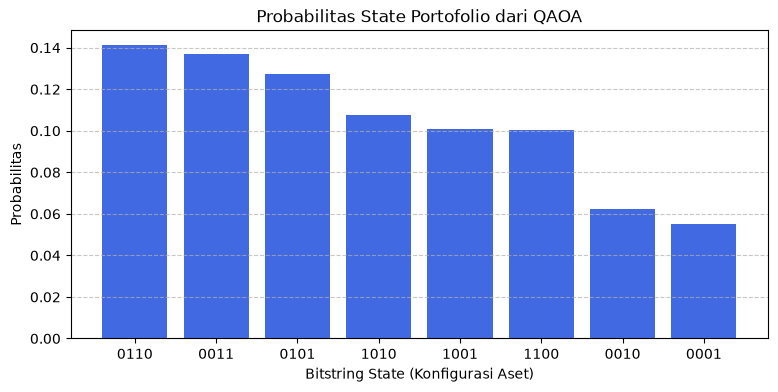

In [6]:
# 1. Tampilkan Perbandingan Aset
selected_exact = [tickers[i] for i, val in enumerate(result_exact.x) if val == 1]
selected_qaoa = [tickers[i] for i, val in enumerate(result_qaoa_x) if val == 1]

print("=== BENCHMARK PERBANDINGAN ===")
print(f"Pilihan Klasik (Exact) : {selected_exact} (Obj: {result_exact.fval:.4f})")
print(f"Pilihan Kuantum (QAOA) : {selected_qaoa} (Obj: {result_qaoa_fval:.4f})")
print(f"Solusi Identik         : {'YA (Optimal 100%)' if np.array_equal(result_exact.x, result_qaoa_x) else 'TIDAK (Sub-optimal)'}")

# 2. Visualisasi Distribusi Probabilitas State QAOA
plt.figure(figsize=(9, 4))
top_states = sorted(probabilities.items(), key=lambda item: item[1], reverse=True)[:8]
plt.bar([item[0] for item in top_states], [item[1] for item in top_states], color='royalblue')
plt.title("Probabilitas State Portofolio dari QAOA")
plt.xlabel("Bitstring State (Konfigurasi Aset)")
plt.ylabel("Probabilitas")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

=== Sirkuit Kuantum QAOA ===


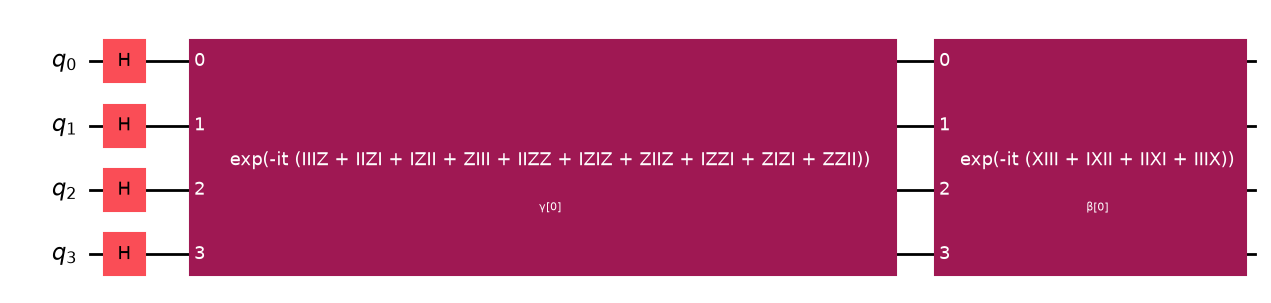

In [7]:
# Tampilkan sirkuit QAOA versi teks / ASCII
print("=== Sirkuit Kuantum QAOA ===")
ansatz.decompose().draw('mpl', fold=-1)

In [8]:
risk_free_rate = 0.06  # Asumsi suku bunga BI 6%

# Ekstrak return dan volatilitas portofolio terpilih (bobot dibagi rata antar aset terpilih)
weights = result_qaoa_x / np.sum(result_qaoa_x)
port_return = np.dot(weights, mu)
port_volatility = np.sqrt(np.dot(weights.T, np.dot(sigma, weights)))
sharpe_ratio = (port_return - risk_free_rate) / port_volatility

print("=== METRIK FINANSIAL PORTOFOLIO QAOA ===")
print(f"Alokasi Bobot     : {dict(zip(tickers, np.round(weights, 2)))}")
print(f"Expected Return   : {port_return * 100:.2f}% per tahun")
print(f"Volatilitas (Risk): {port_volatility * 100:.2f}% per tahun")
print(f"Sharpe Ratio      : {sharpe_ratio:.3f}")

=== METRIK FINANSIAL PORTOFOLIO QAOA ===
Alokasi Bobot     : {'BBCA.JK': np.float64(0.0), 'TLKM.JK': np.float64(0.5), 'ASII.JK': np.float64(0.5), 'BMRI.JK': np.float64(0.0)}
Expected Return   : 5.26% per tahun
Volatilitas (Risk): 23.17% per tahun
Sharpe Ratio      : -0.032


c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


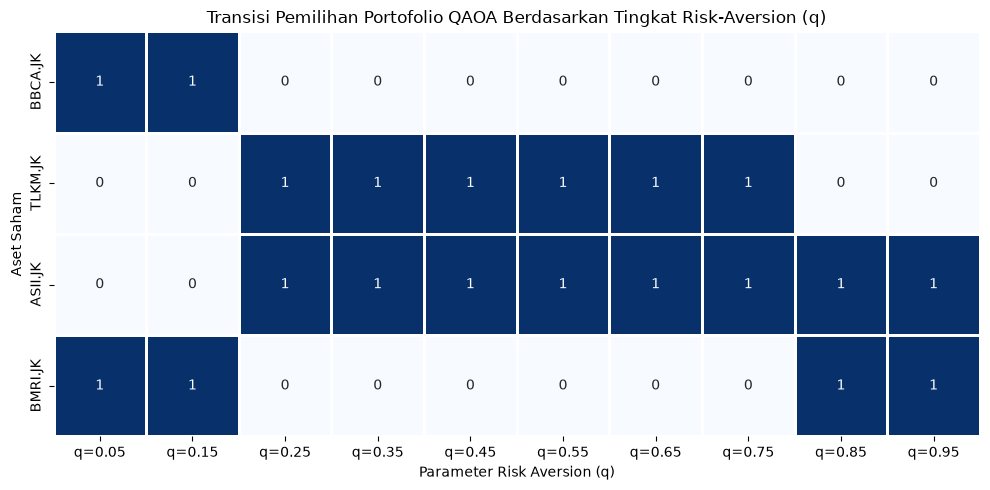

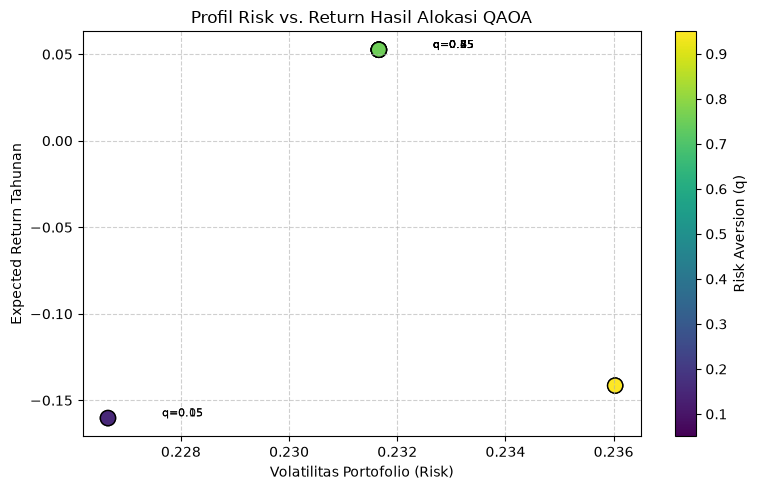

In [9]:
# ==========================================
# EKSPERIMEN 1: SENSITIVITAS RISK AVERSION (q)
# ==========================================
import seaborn as sns

q_values = np.linspace(0.05, 0.95, 10)
asset_selection_history = []
portfolio_returns = []
portfolio_risks = []
sharpe_ratios = []

for q_val in q_values:
    # 1. Bangun Quadratic Program untuk nilai q spesifik
    qp_temp = QuadraticProgram()
    for ticker in tickers:
        qp_temp.binary_var(name=ticker)
    
    linear_terms = {tickers[i]: -float(mu[i]) for i in range(num_assets)}
    quadratic_terms = {}
    for i in range(num_assets):
        for j in range(num_assets):
            val = q_val * float(sigma[i, j])
            if val != 0:
                quadratic_terms[(tickers[i], tickers[j])] = val
                
    qp_temp.minimize(linear=linear_terms, quadratic=quadratic_terms)
    qp_temp.linear_constraint(
        linear={ticker: 1 for ticker in tickers},
        sense="==",
        rhs=budget
    )
    
    # 2. Konversi ke Ising & Selesaikan dengan QAOA (p=1)
    qubo_temp = conv.convert(qp_temp)
    op_temp, _ = qubo_temp.to_ising()
    ansatz_temp = QAOAAnsatz(cost_operator=op_temp, reps=1)
    
    def cost_temp(params):
        circ = ansatz_temp.assign_parameters(params)
        return Statevector.from_instruction(circ).expectation_value(op_temp).real

    res_opt = minimize(cost_temp, np.ones(ansatz_temp.num_parameters)*0.5, method='COBYLA')
    best_circ = ansatz_temp.assign_parameters(res_opt.x)
    probs = Statevector.from_instruction(best_circ).probabilities_dict()
    best_state = max(probs, key=probs.get)
    x_sol = np.array([int(b) for b in reversed(best_state)])
    
    asset_selection_history.append(x_sol)
    
    # Hitung metrik portofolio
    w = x_sol / np.sum(x_sol)
    ret = np.dot(w, mu)
    vol = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
    sr = (ret - 0.06) / vol if vol > 0 else 0
    portfolio_returns.append(ret)
    portfolio_risks.append(vol)
    sharpe_ratios.append(sr)

# --- VISUALISASI 1: Heatmap Alokasi Saham vs Risk Factor ---
plt.figure(figsize=(10, 5))
heatmap_data = pd.DataFrame(
    asset_selection_history, 
    index=[f"q={round(q, 2)}" for q in q_values], 
    columns=tickers
).T

sns.heatmap(heatmap_data, annot=True, cmap="Blues", cbar=False, linewidths=1)
plt.title("Transisi Pemilihan Portofolio QAOA Berdasarkan Tingkat Risk-Aversion (q)")
plt.xlabel("Parameter Risk Aversion (q)")
plt.ylabel("Aset Saham")
plt.tight_layout()
plt.savefig("../assets/q_sensitivity_heatmap.png", dpi=300)
plt.show()

# --- VISUALISASI 2: Risk-Return Scatter / Pseudo-Efficient Frontier ---
plt.figure(figsize=(8, 5))
scatter = plt.scatter(portfolio_risks, portfolio_returns, c=q_values, cmap='viridis', s=120, edgecolors='black')
plt.colorbar(scatter, label='Risk Aversion (q)')
for i, txt in enumerate(q_values):
    plt.annotate(f"q={txt:.2f}", (portfolio_risks[i]+0.001, portfolio_returns[i]+0.001), fontsize=8)

plt.title("Profil Risk vs. Return Hasil Alokasi QAOA")
plt.xlabel("Volatilitas Portofolio (Risk)")
plt.ylabel("Expected Return Tahunan")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("../assets/risk_return_frontier.png", dpi=300)
plt.show()

c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_dsolve\linsolve.py:653: SparseEfficiencyWarning: splu converted its input to CSC format
  return splu(A).solve
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\linalg\_matfuncs.py:706: SparseEfficiencyWarning: spsolve is more efficient when sparse b is in the CSC matrix format
  return spsolve(Q, P)
c:\Users\User\Documents\Coding\data analyst\q markowitz\venv\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


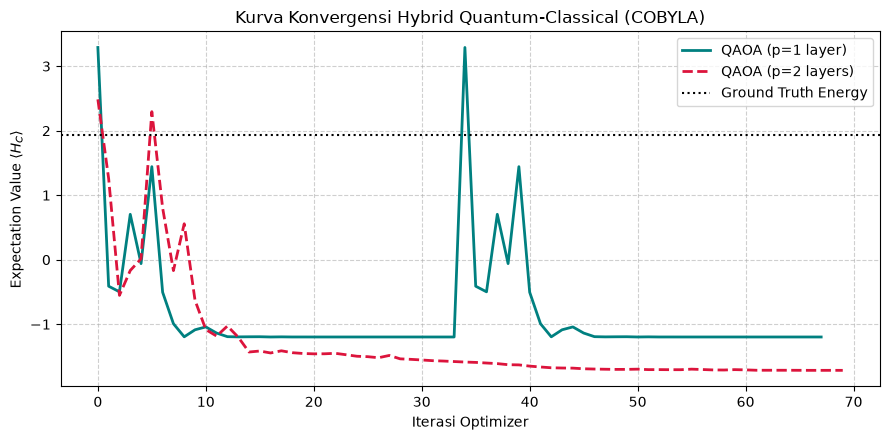

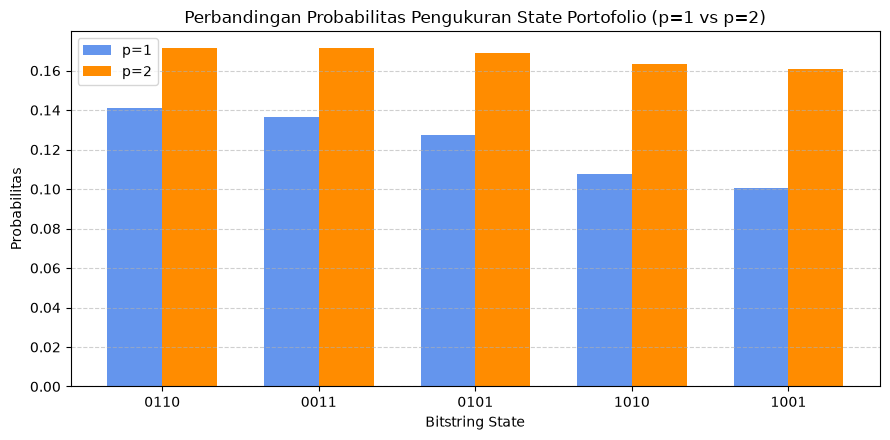

In [10]:
# ==========================================
# EKSPERIMEN 2: PERBANDINGAN DEPTH QAOA (p=1 vs p=2)
# ==========================================
conv_p1, conv_p2 = [], []

# QAOA p=1
ansatz_p1 = QAOAAnsatz(cost_operator=operator, reps=1)
def cost_p1(params):
    c = ansatz_p1.assign_parameters(params)
    val = Statevector.from_instruction(c).expectation_value(operator).real
    conv_p1.append(val)
    return val

minimize(cost_p1, np.ones(ansatz_p1.num_parameters) * 0.5, method='COBYLA', options={'maxiter': 80})

# QAOA p=2
ansatz_p2 = QAOAAnsatz(cost_operator=operator, reps=2)
def cost_p2(params):
    c = ansatz_p2.assign_parameters(params)
    val = Statevector.from_instruction(c).expectation_value(operator).real
    conv_p2.append(val)
    return val

minimize(cost_p2, np.ones(ansatz_p2.num_parameters) * 0.5, method='COBYLA', options={'maxiter': 80})

# Ekstrak probabilitas ground truth untuk kedua sirkuit
best_p1_circ = ansatz_p1.assign_parameters(minimize(cost_p1, np.ones(ansatz_p1.num_parameters)*0.5, method='COBYLA').x)
best_p2_circ = ansatz_p2.assign_parameters(minimize(cost_p2, np.ones(ansatz_p2.num_parameters)*0.5, method='COBYLA').x)

prob_p1 = Statevector.from_instruction(best_p1_circ).probabilities_dict()
prob_p2 = Statevector.from_instruction(best_p2_circ).probabilities_dict()

# --- VISUALISASI 3: Kurva Konvergensi Optimizer (Energi Ekspektasi) ---
plt.figure(figsize=(9, 4.5))
plt.plot(conv_p1[:70], label="QAOA (p=1 layer)", color="teal", linewidth=2)
plt.plot(conv_p2[:70], label="QAOA (p=2 layers)", color="crimson", linewidth=2, linestyle="--")
plt.axhline(y=result_exact.fval + offset, color="black", linestyle=":", label="Ground Truth Energy")
plt.title("Kurva Konvergensi Hybrid Quantum-Classical (COBYLA)")
plt.xlabel("Iterasi Optimizer")
plt.ylabel(r"Expectation Value $\langle H_C \rangle$")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("../assets/convergence_comparison.png", dpi=300)
plt.show()

# --- VISUALISASI 4: Perbandingan Probabilitas State p=1 vs p=2 ---
all_states = sorted(list(set(list(prob_p1.keys()) + list(prob_p2.keys()))))
top_5_states = sorted(all_states, key=lambda s: prob_p1.get(s, 0), reverse=True)[:5]

x_indices = np.arange(len(top_5_states))
bar_width = 0.35

plt.figure(figsize=(9, 4.5))
plt.bar(x_indices - bar_width/2, [prob_p1.get(s, 0) for s in top_5_states], width=bar_width, label="p=1", color="cornflowerblue")
plt.bar(x_indices + bar_width/2, [prob_p2.get(s, 0) for s in top_5_states], width=bar_width, label="p=2", color="darkorange")
plt.xticks(x_indices, top_5_states)
plt.title("Perbandingan Probabilitas Pengukuran State Portofolio (p=1 vs p=2)")
plt.xlabel("Bitstring State")
plt.ylabel("Probabilitas")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("../assets/probability_depth_comparison.png", dpi=300)
plt.show()

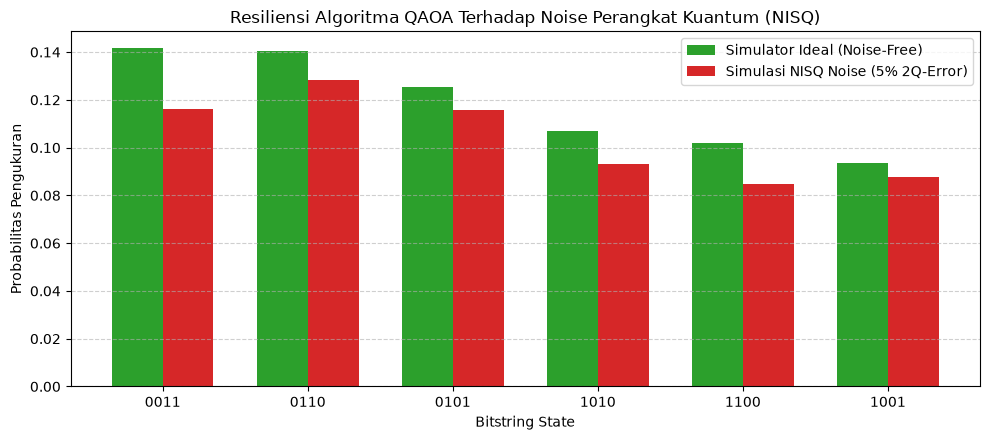

In [11]:
# ==========================================
# EKSPERIMEN 3: SIMULASI NOISE HARDWARE NISQ
# ==========================================
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit import transpile

# 1. Bangun Noise Model buatan (Simulasi Quantum Hardware Nyata)
noise_model = NoiseModel()
# Tambahkan 1% error pada single-qubit gates dan 5% error pada two-qubit entangling gates
error_1q = depolarizing_error(0.01, 1)
error_2q = depolarizing_error(0.05, 2)
noise_model.add_all_qubit_quantum_error(error_1q, ['rx', 'h'])
noise_model.add_all_qubit_quantum_error(error_2q, ['cx', 'rzz'])

# 2. Siapkan sirkuit QAOA dengan pengukuran eksplisit
circuit_to_measure = optimal_circuit.copy()
circuit_to_measure.measure_all()

# 3. Jalankan di AerSimulator (Ideal vs Noisy)
backend_ideal = AerSimulator()
backend_noisy = AerSimulator(noise_model=noise_model)

shots = 4096
ideal_transpiled = transpile(circuit_to_measure, backend_ideal)
noisy_transpiled = transpile(circuit_to_measure, backend_noisy)

counts_ideal = backend_ideal.run(ideal_transpiled, shots=shots).result().get_counts()
counts_noisy = backend_noisy.run(noisy_transpiled, shots=shots).result().get_counts()

# Normalisasi menjadi probabilitas
prob_ideal_sim = {k: v / shots for k, v in counts_ideal.items()}
prob_noisy_sim = {k: v / shots for k, v in counts_noisy.items()}

# --- VISUALISASI 5: Ideal Simulator vs NISQ Noisy Hardware ---
eval_states = sorted(prob_ideal_sim.keys(), key=lambda s: prob_ideal_sim[s], reverse=True)[:6]
x_axis = np.arange(len(eval_states))

plt.figure(figsize=(10, 4.5))
plt.bar(x_axis - bar_width/2, [prob_ideal_sim.get(s, 0) for s in eval_states], width=bar_width, label="Simulator Ideal (Noise-Free)", color="#2ca02c")
plt.bar(x_axis + bar_width/2, [prob_noisy_sim.get(s, 0) for s in eval_states], width=bar_width, label="Simulasi NISQ Noise (5% 2Q-Error)", color="#d62728")
plt.xticks(x_axis, eval_states)
plt.title("Resiliensi Algoritma QAOA Terhadap Noise Perangkat Kuantum (NISQ)")
plt.xlabel("Bitstring State")
plt.ylabel("Probabilitas Pengukuran")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig("../assets/nisq_noise_impact.png", dpi=300)
plt.show()